# Day 3: Classification — Solutions

**Warning:** Try to complete the exercises in `demos/05_SupervisedML_Classification.ipynb` on your own before looking at these solutions!

---

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_blobs, load_iris, load_breast_cancer

print("✓ Libraries imported!")

✓ Libraries imported!


### Prepare datasets used across solutions

In [2]:
# Blob data (used for KNN Task 1)
data, labels = make_blobs(n_samples=500, centers=4, cluster_std=0.75, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.20, random_state=42)

# Iris data (used for Exercise 2)
iris = load_iris()
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=42, stratify=iris.target
)

# Breast cancer data (used for Exercise 3)
cancer = load_breast_cancer(as_frame=True)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    cancer.data, cancer.target, test_size=0.25, stratify=cancer.target, random_state=42
)

print("✓ Datasets ready!")

✓ Datasets ready!


---

## Task 1: KNN from Scratch

### Solution

In [3]:
def knn_predict(new_point, experience_data, experience_labels, k):
    # Step 1: Calculate Euclidean distance to all training points
    distances = np.sqrt(np.sum((experience_data - new_point)**2, axis=1))
    
    # Step 2: Find the indices of the k smallest distances
    k_nearest_indices = np.argsort(distances)[:k]
    
    # Step 3: Get the labels of those k nearest neighbors
    k_nearest_labels = experience_labels[k_nearest_indices]
    
    # Step 4: Return the most common label (majority vote)
    predicted_class = np.bincount(k_nearest_labels).argmax()
    
    return predicted_class

# Test it
k = 5
correct = 0
for i in range(10):
    pred = knn_predict(X_test[i], X_train, y_train, k)
    actual = y_test[i]
    match = '✓' if pred == actual else '✗'
    if pred == actual:
        correct += 1
    print(f"Point {i}: Predicted={pred}, Actual={actual} {match}")

print(f"\nAccuracy: {correct}/10 ({correct/10:.0%})")

Point 0: Predicted=0, Actual=0 ✓
Point 1: Predicted=3, Actual=3 ✓
Point 2: Predicted=3, Actual=3 ✓
Point 3: Predicted=3, Actual=3 ✓
Point 4: Predicted=3, Actual=3 ✓
Point 5: Predicted=2, Actual=2 ✓
Point 6: Predicted=1, Actual=1 ✓
Point 7: Predicted=3, Actual=3 ✓
Point 8: Predicted=1, Actual=1 ✓
Point 9: Predicted=1, Actual=1 ✓

Accuracy: 10/10 (100%)


**Explanation:**
- `np.sqrt(np.sum((experience_data - new_point)**2, axis=1))` broadcasts `new_point` across all training rows and computes the Euclidean distance to each
- `np.argsort(distances)[:k]` returns indices that would sort the array, then we take the first `k` (smallest distances)
- `np.bincount(labels).argmax()` counts occurrences of each label value and returns the most frequent one (majority vote)

---

## Exercise 1: Titanic Survival Prediction

### Solution

In [4]:
# Step 1: Load
titanic = pd.read_csv('../datasets/titanic.csv')
print(f"Dataset: {titanic.shape}")
print(f"\nMissing values:")
print(titanic.isnull().sum())

Dataset: (887, 8)

Missing values:
Survived                   0
Pclass                     0
Name                       1
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64


In [5]:
# Step 2: Preprocess
features = ['Pclass', 'Sex', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare']
df = titanic[features + ['Survived']].copy()

# Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Encode categorical variables
df = pd.get_dummies(df, columns=['Sex'], drop_first=True)

# Define X and y
X_titanic = df.drop('Survived', axis=1)
y_titanic = df['Survived']

# Split
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic, y_titanic, test_size=0.25, random_state=42, stratify=y_titanic
)

print(f"Training: {len(X_train_t)}, Test: {len(X_test_t)}")
print(f"Features: {list(X_titanic.columns)}")

Training: 665, Test: 222
Features: ['Pclass', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare', 'Sex_male']


In [6]:
# Step 3 & 4: Train and compare models

# Scale features (important for KNN and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_t)
X_test_scaled = scaler.transform(X_test_t)

models = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (linear)': SVC(kernel='linear', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42)
}

for name, model in models.items():
    # Use scaled data for KNN and SVM, original for Decision Tree
    if 'Tree' in name:
        model.fit(X_train_t, y_train_t)
        y_pred = model.predict(X_test_t)
    else:
        model.fit(X_train_scaled, y_train_t)
        y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test_t, y_pred)
    print(f"\n{'='*50}")
    print(f"{name}: Accuracy = {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_test_t, y_pred, target_names=['Died', 'Survived']))


KNN (k=5): Accuracy = 0.7748
              precision    recall  f1-score   support

        Died       0.80      0.85      0.82       136
    Survived       0.73      0.66      0.70        86

    accuracy                           0.77       222
   macro avg       0.76      0.75      0.76       222
weighted avg       0.77      0.77      0.77       222


SVM (linear): Accuracy = 0.7703
              precision    recall  f1-score   support

        Died       0.79      0.86      0.82       136
    Survived       0.74      0.63      0.68        86

    accuracy                           0.77       222
   macro avg       0.76      0.74      0.75       222
weighted avg       0.77      0.77      0.77       222


Decision Tree: Accuracy = 0.8108
              precision    recall  f1-score   support

        Died       0.81      0.91      0.86       136
    Survived       0.82      0.65      0.73        86

    accuracy                           0.81       222
   macro avg       0.81      0.

**Explanation:**
- We selected 6 features and dropped `Cabin` (too many missing values) and `Name`/`Ticket`/`Embarked` (not useful or would need more complex encoding)
- `Age` missing values are filled with the median (a robust central tendency measure)
- `Sex` is encoded as a binary column using `pd.get_dummies(drop_first=True)`: Male=1, Female=0
- `StandardScaler` is essential for KNN and SVM since they rely on distances between points; different feature scales would bias results
- Decision Trees don't need scaling because they split on individual feature thresholds
- SVM typically performs best on this dataset due to the high-dimensional feature space and clear margin of separation

---

## Exercise 2: KNN Parameter Tuning

### Solution

k= 1: Train=1.0000  Test=0.9333
k= 2: Train=0.9905  Test=0.9111
k= 3: Train=0.9619  Test=0.9556
k= 4: Train=0.9810  Test=0.9556
k= 5: Train=0.9714  Test=0.9778
k= 6: Train=0.9619  Test=0.9556
k= 7: Train=0.9714  Test=0.9556
k= 8: Train=0.9714  Test=0.9333
k= 9: Train=0.9714  Test=0.9556
k=10: Train=0.9714  Test=0.9556
k=11: Train=0.9714  Test=0.9333
k=12: Train=0.9714  Test=0.9333
k=13: Train=0.9810  Test=0.9333
k=14: Train=0.9619  Test=0.9333
k=15: Train=0.9810  Test=0.9556

Best k = 5 with test accuracy = 0.9778


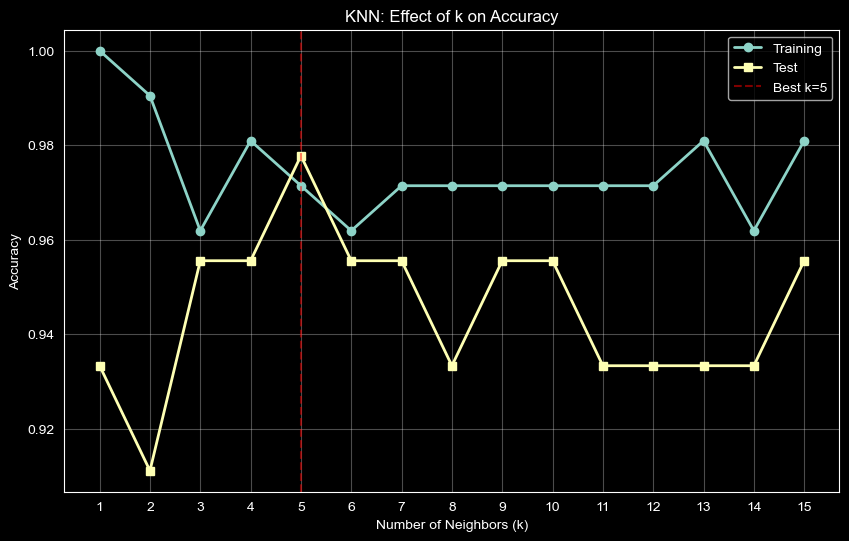

In [7]:
k_values = range(1, 16)
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_iris, y_train_iris)
    
    train_acc = knn.score(X_train_iris, y_train_iris)
    test_acc = knn.score(X_test_iris, y_test_iris)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"k={k:>2d}: Train={train_acc:.4f}  Test={test_acc:.4f}")

# Find best k
best_k = list(k_values)[np.argmax(test_accuracies)]
best_acc = max(test_accuracies)
print(f"\nBest k = {best_k} with test accuracy = {best_acc:.4f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(list(k_values), train_accuracies, 'o-', label='Training', linewidth=2)
plt.plot(list(k_values), test_accuracies, 's-', label='Test', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.5, label=f'Best k={best_k}')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN: Effect of k on Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(list(k_values))
plt.show()

**Explanation:**
- At k=1, training accuracy is 100% (each point is its own nearest neighbor) but test accuracy may be lower — this is overfitting
- As k increases, the model becomes smoother and more robust but may underfit
- The best k balances between overfitting (k too small) and underfitting (k too large)
- Typically odd values of k are preferred to avoid tie-breaking issues in binary classification

---

## Exercise 3: SVM Kernel Comparison

### Solution

In [8]:
kernels = ['linear', 'rbf', 'poly']

print(f"{'Kernel':<10} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 32)

for kernel in kernels:
    svm_model = SVC(kernel=kernel, random_state=42)
    svm_model.fit(X_train_c, y_train_c)
    
    train_acc = svm_model.score(X_train_c, y_train_c)
    test_acc = svm_model.score(X_test_c, y_test_c)
    print(f"{kernel:<10} {train_acc:>10.4f} {test_acc:>10.4f}")

print("\nNote: The linear kernel often works best for the breast cancer dataset")
print("because the 30 features already provide good linear separability.")
print("Non-linear kernels (rbf, poly) may overfit or underperform")
print("when the data is already mostly linearly separable.")

Kernel      Train Acc   Test Acc
--------------------------------
linear         0.9624     0.9510
rbf            0.9178     0.9231
poly           0.9085     0.9161

Note: The linear kernel often works best for the breast cancer dataset
because the 30 features already provide good linear separability.
Non-linear kernels (rbf, poly) may overfit or underperform
when the data is already mostly linearly separable.


**Explanation:**
- The `linear` kernel draws a straight hyperplane; it works well when classes are linearly separable
- The `rbf` (Radial Basis Function) kernel maps data to a higher-dimensional space to find curved boundaries
- The `poly` kernel uses polynomial functions for the boundary
- For high-dimensional data like the breast cancer dataset (30 features), linear kernels often suffice because there's more "room" for linear separation in high dimensions
- More complex kernels aren't always better — they can overfit on smaller datasets